In [18]:
%pip install pandas matplotlib seaborn plotly kaleido nbformat

  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached referencing-0.37.0-py3-none-any.whl.metadata (2.8 kB)
Using cached jsonschema-4.26.0-py3-none-any.whl (90 kB)
Using cached attrs-26.1.0-py3-none-any.whl (67 kB)
Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl (18 kB)
Using cached referencing-0.37.0-py3-none-any.whl (26 kB)
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# CELL 1: Setup and Data Loading
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings

warnings.filterwarnings('ignore')
os.makedirs("exports/charts", exist_ok=True)


df_nav = pd.read_csv("D:/capstone/data/processed/nav_history_cleaned.csv")
df_fund = pd.read_csv("D:/capstone/data/processed/fund_master_cleaned.csv")
df_aum = pd.read_csv("D:/capstone/data/processed/aum_by_fund_house_cleaned.csv")
df_sip = pd.read_csv("D:/capstone/data/processed/monthly_sip_inflows_cleaned.csv")
df_cat = pd.read_csv("D:/capstone/data/processed/category_inflows_cleaned.csv")
df_tx = pd.read_csv("D:/capstone/data/processed/investor_transactions_cleaned.csv")
df_folio = pd.read_csv("D:/capstone/data/processed/industry_folio_count_cleaned.csv")
df_holdings = pd.read_csv("D:/capstone/data/processed/portfolio_holdings_cleaned.csv")

df_nav['date'] = pd.to_datetime(df_nav['date'])
df_tx['transaction_date'] = pd.to_datetime(df_tx['transaction_date'])


df_nav_full = pd.merge(df_nav, df_fund[['amfi_code', 'scheme_name']], on='amfi_code', how='left')

print(" setup complete. Data loaded successfully")

✅ Environment setup complete. Data loaded successfully!


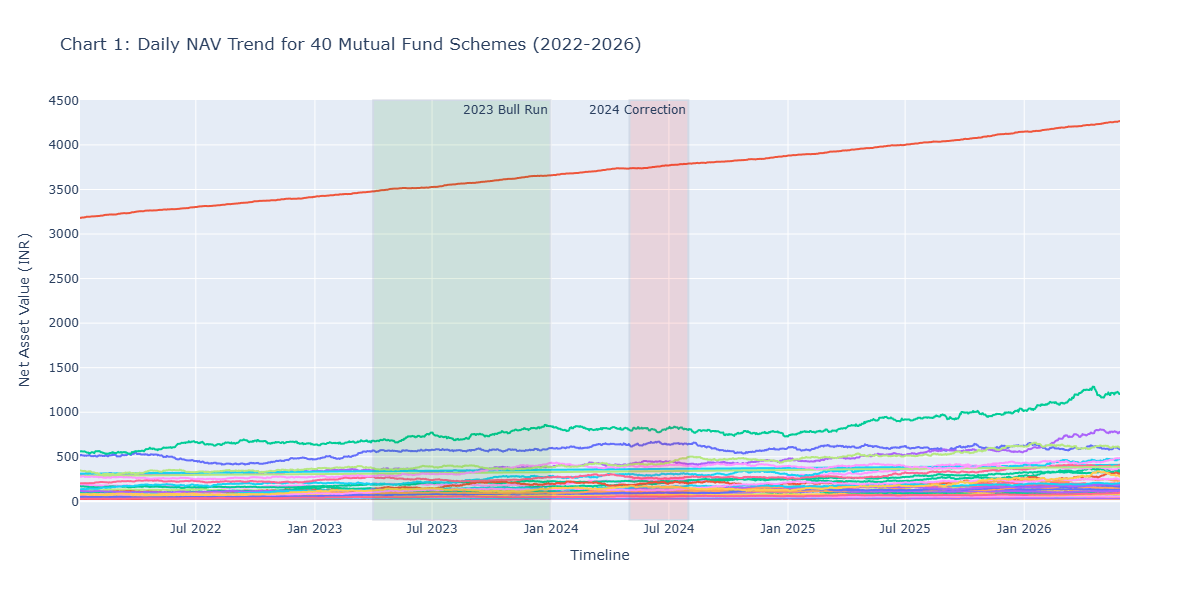

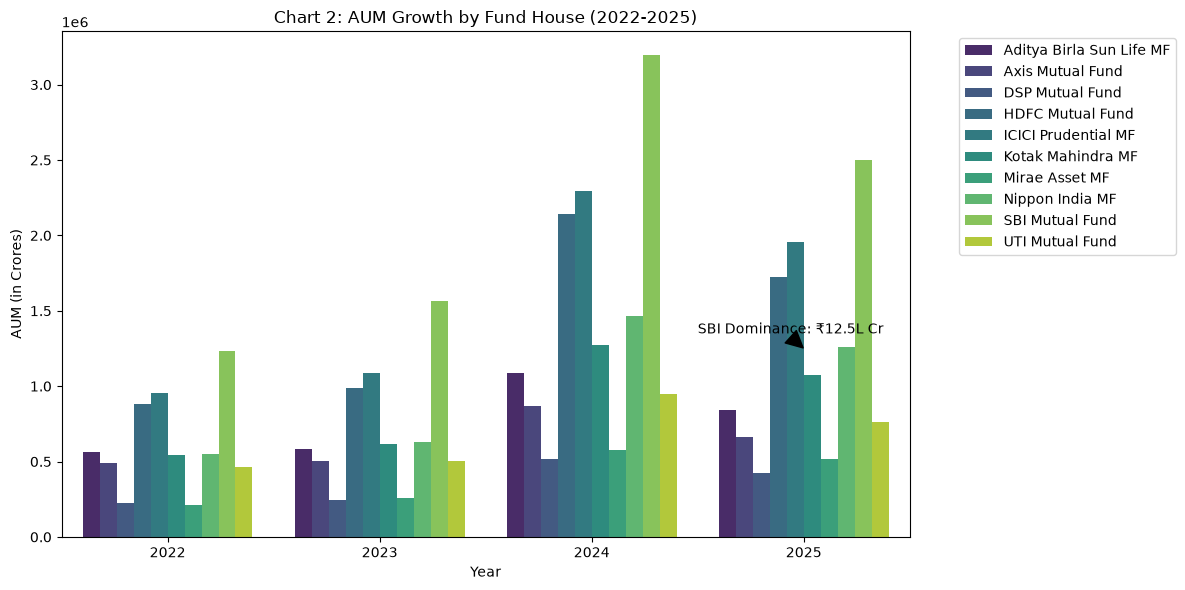

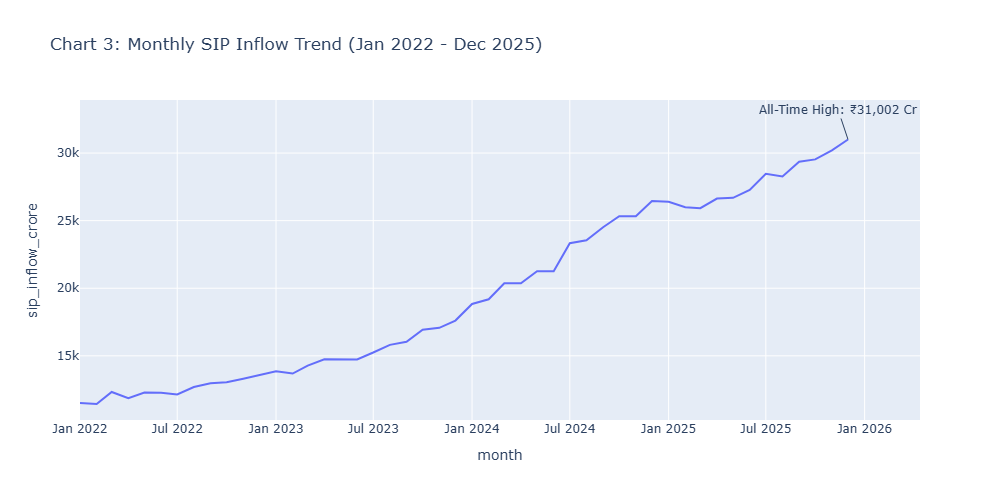

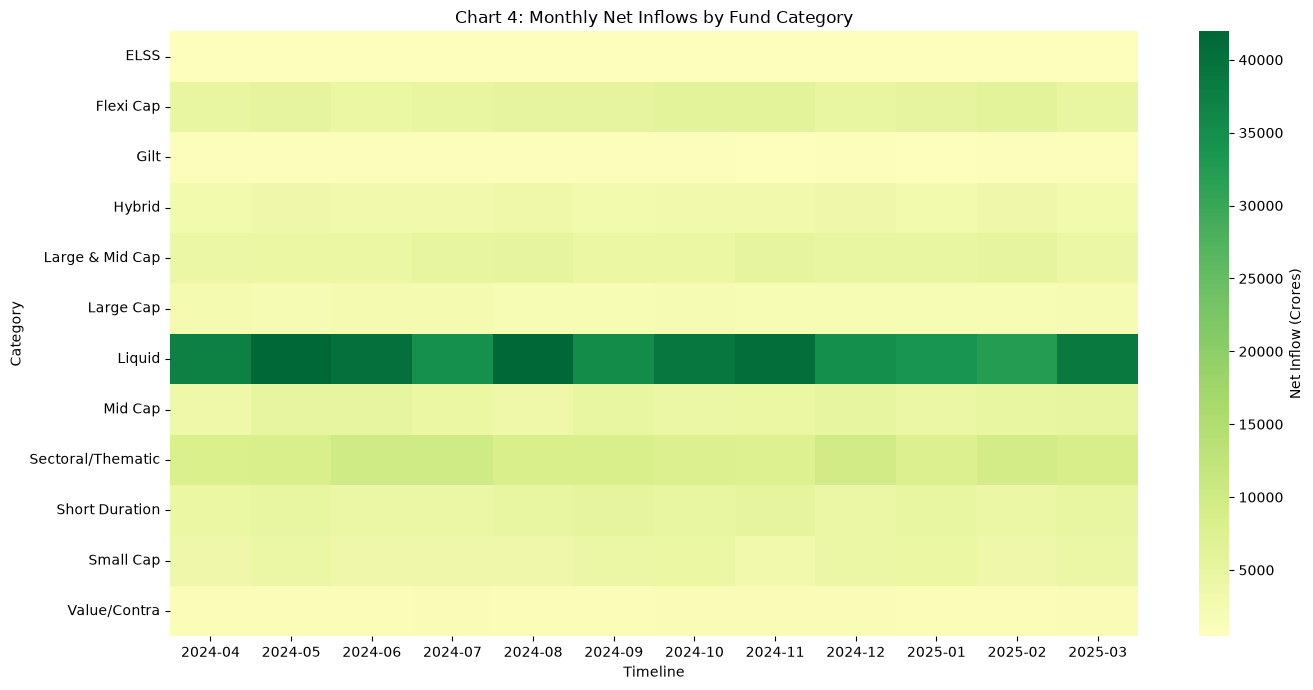

In [ ]:
# CELL 2: Core Macro Performance & Flows


fig1 = px.line(df_nav_full, x='date', y='nav', color='scheme_name', 
               title='Chart 1: Daily NAV Trend for 40 Mutual Fund Schemes (2022-2026)',
               labels={'nav': 'Net Asset Value (INR)', 'date': 'Timeline'})
fig1.add_vrect(x0="2023-04-01", x1="2023-12-31", fillcolor="green", opacity=0.1, annotation_text="2023 Bull Run")
fig1.add_vrect(x0="2024-05-01", x1="2024-07-31", fillcolor="red", opacity=0.1, annotation_text="2024 Correction")
fig1.update_layout(showlegend=False)
fig1.write_image("exports/charts/01_nav_trend.png", width=1200, height=600)
display(Image(filename="exports/charts/01_nav_trend.png"))


df_aum['year'] = pd.to_datetime(df_aum['date']).dt.year
aum_yearly = df_aum.groupby(['year', 'fund_house'])['aum_crore'].sum().reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(data=aum_yearly, x='year', y='aum_crore', hue='fund_house', palette='viridis')
plt.title('Chart 2: AUM Growth by Fund House (2022-2025)')
plt.ylabel('AUM (in Crores)')
plt.xlabel('Year')
plt.annotate('SBI Dominance: ₹12.5L Cr', xy=(3, 1250000), xytext=(2.5, 1350000),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("exports/charts/02_aum_growth.png")
plt.show()

fig3 = px.line(df_sip, x='month', y='sip_inflow_crore', 
               title='Chart 3: Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)')
fig3.add_annotation(x="2025-12-01", y=31002, text="All-Time High: ₹31,002 Cr", showarrow=True)
fig3.write_image("exports/charts/03_sip_inflows.png", width=1000, height=500)
display(Image(filename="exports/charts/03_sip_inflows.png"))


df_cat['month_year'] = pd.to_datetime(df_cat['month']).dt.strftime('%Y-%m')
heatmap_data = df_cat.pivot_table(index='category', columns='month_year', values='net_inflow_crore', aggfunc='sum')
plt.figure(figsize=(14, 7))
sns.heatmap(heatmap_data, cmap='RdYlGn', center=0, cbar_kws={'label': 'Net Inflow (Crores)'})
plt.title('Chart 4: Monthly Net Inflows by Fund Category')
plt.ylabel('Category')
plt.xlabel('Timeline')
plt.tight_layout()
plt.savefig("exports/charts/04_category_heatmap.png")
plt.show()

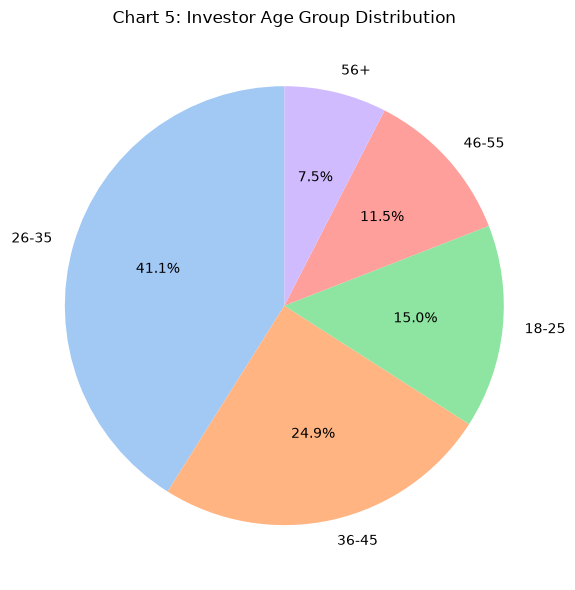

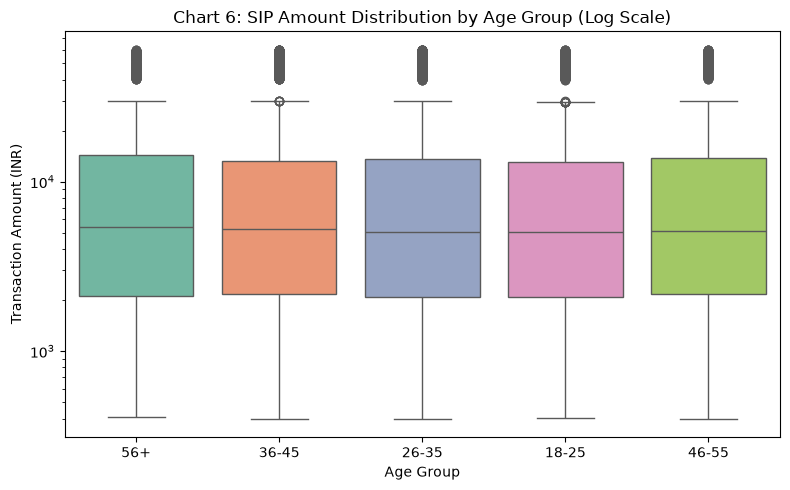

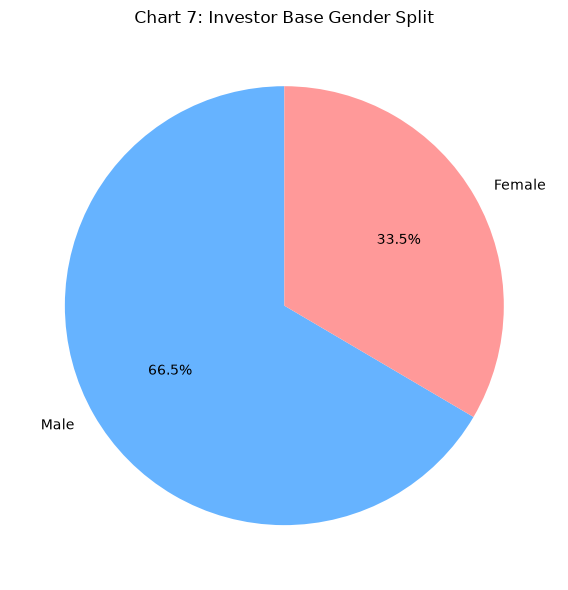

In [ ]:
# CELL 3: Investor Profile & Demographics


plt.figure(figsize=(6, 6))
df_tx['age_group'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=sns.color_palette("pastel"))
plt.title('Chart 5: Investor Age Group Distribution')
plt.ylabel('')
plt.tight_layout()
plt.savefig("exports/charts/05_demographics_age.png")
plt.show()


plt.figure(figsize=(8, 5))
sip_tx = df_tx[df_tx['transaction_type'] == 'SIP']
sns.boxplot(data=sip_tx, x='age_group', y='amount_inr', palette="Set2")
plt.yscale('log')
plt.title('Chart 6: SIP Amount Distribution by Age Group (Log Scale)')
plt.ylabel('Transaction Amount (INR)')
plt.xlabel('Age Group')
plt.tight_layout()
plt.savefig("exports/charts/06_demographics_boxplot.png")
plt.show()


plt.figure(figsize=(6, 6))
df_tx['gender'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ff9999'])
plt.title('Chart 7: Investor Base Gender Split')
plt.ylabel('')
plt.tight_layout()
plt.savefig("exports/charts/07_demographics_gender.png")
plt.show()

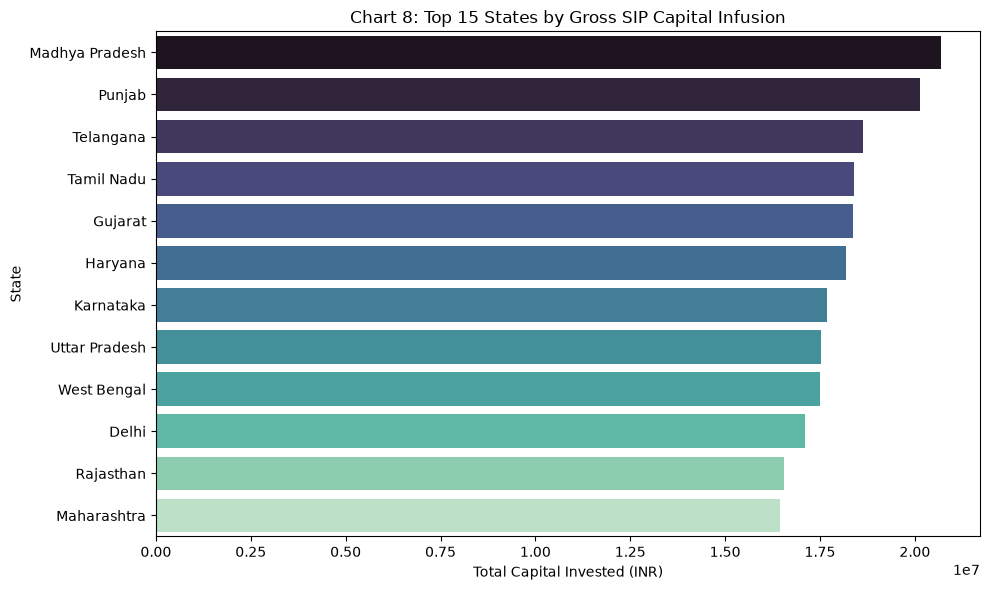

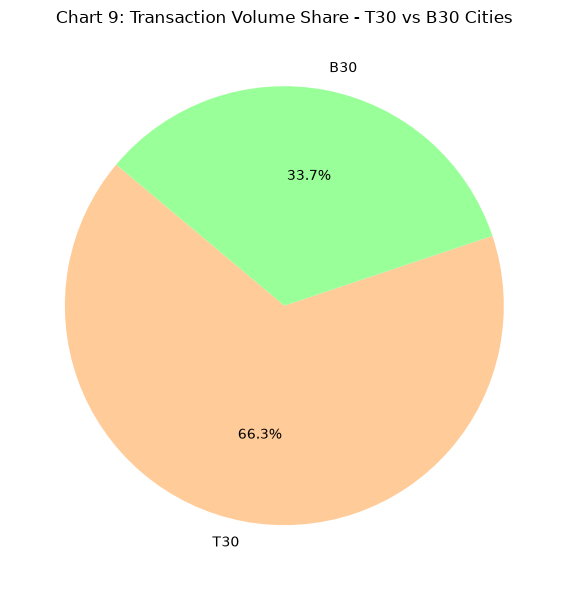

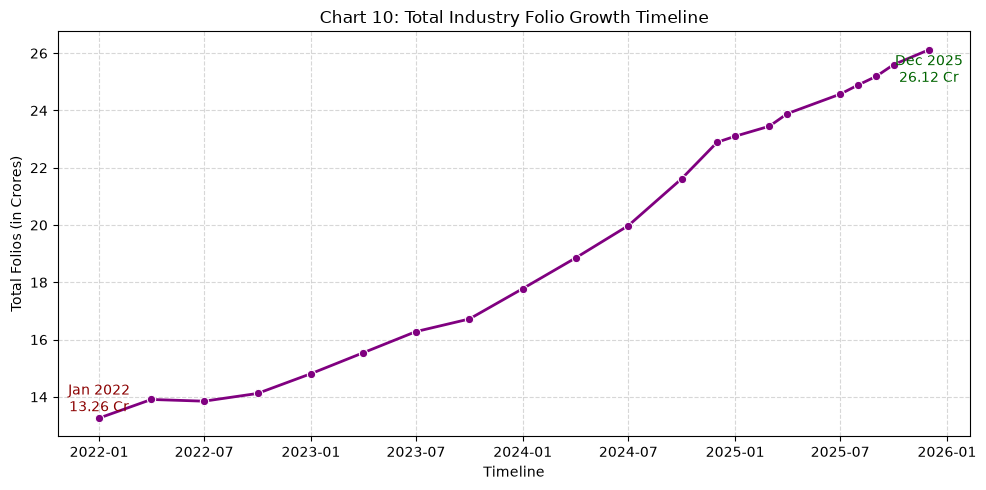

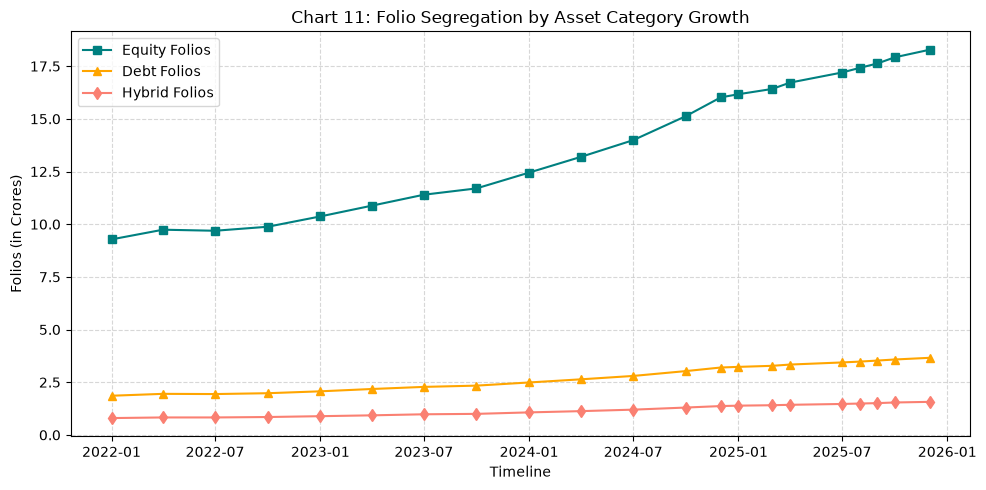

In [27]:
# CELL 4: Geographic & Folio Milestones


plt.figure(figsize=(10, 6))
state_sip = sip_tx.groupby('state')['amount_inr'].sum().sort_values(ascending=False).head(15)
sns.barplot(x=state_sip.values, y=state_sip.index, palette="mako")
plt.title('Chart 8: Top 15 States by Gross SIP Capital Infusion')
plt.xlabel('Total Capital Invested (INR)')
plt.ylabel('State')
plt.tight_layout()
plt.savefig("exports/charts/08_geographic_states.png")
plt.show()


plt.figure(figsize=(6, 6))
df_tx['city_tier'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#ffcc99', '#99ff99'], startangle=140)
plt.title('Chart 9: Transaction Volume Share - T30 vs B30 Cities')
plt.ylabel('')
plt.tight_layout()
plt.savefig("exports/charts/09_geographic_tier.png")
plt.show()


plt.figure(figsize=(10, 5))
df_folio['month_dt'] = pd.to_datetime(df_folio['month'])
sns.lineplot(data=df_folio, x='month_dt', y='total_folios_crore', marker="o", color="purple", linewidth=2)
plt.title('Chart 10: Total Industry Folio Growth Timeline')
plt.ylabel('Total Folios (in Crores)')
plt.xlabel('Timeline')
plt.text(df_folio['month_dt'].min(), 13.5, 'Jan 2022\n13.26 Cr', ha='center', color='darkred')
plt.text(df_folio['month_dt'].max(), 25.0, 'Dec 2025\n26.12 Cr', ha='center', color='darkgreen')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("exports/charts/10_folio_total_growth.png")
plt.show()


plt.figure(figsize=(10, 5))
plt.plot(df_folio['month_dt'], df_folio['equity_folios_crore'], label='Equity Folios', marker='s', color='teal')
plt.plot(df_folio['month_dt'], df_folio['debt_folios_crore'], label='Debt Folios', marker='^', color='orange')
plt.plot(df_folio['month_dt'], df_folio['hybrid_folios_crore'], label='Hybrid Folios', marker='d', color='salmon')
plt.title('Chart 11: Folio Segregation by Asset Category Growth')
plt.ylabel('Folios (in Crores)')
plt.xlabel('Timeline')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("exports/charts/11_folio_segment_breakdown.png")
plt.show()

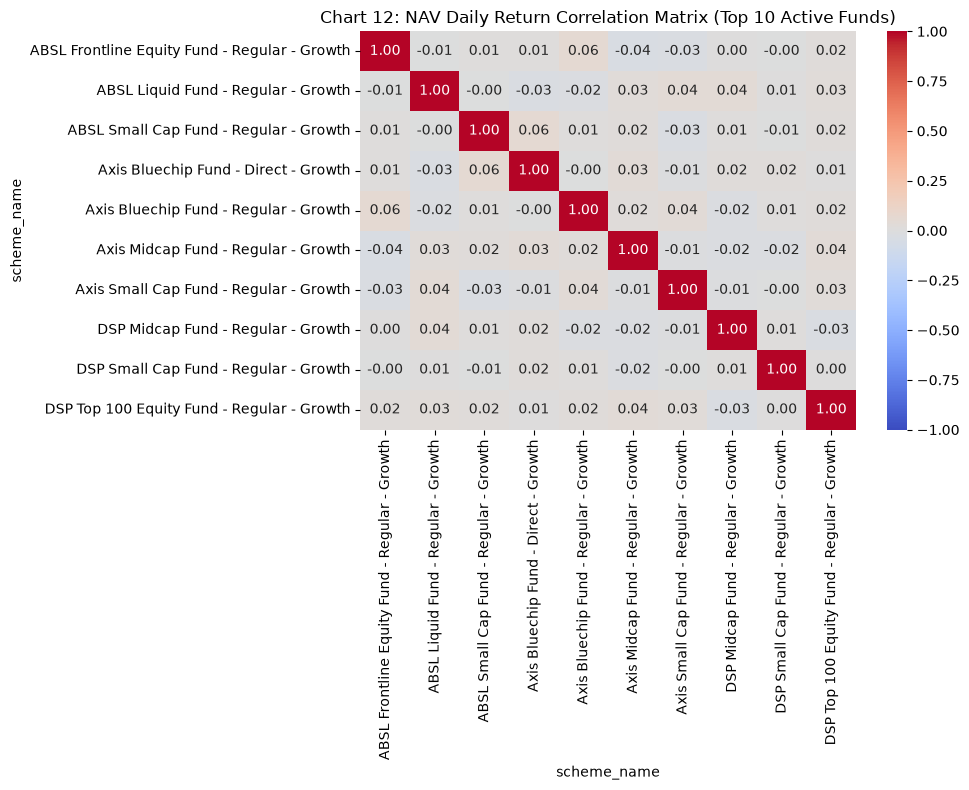

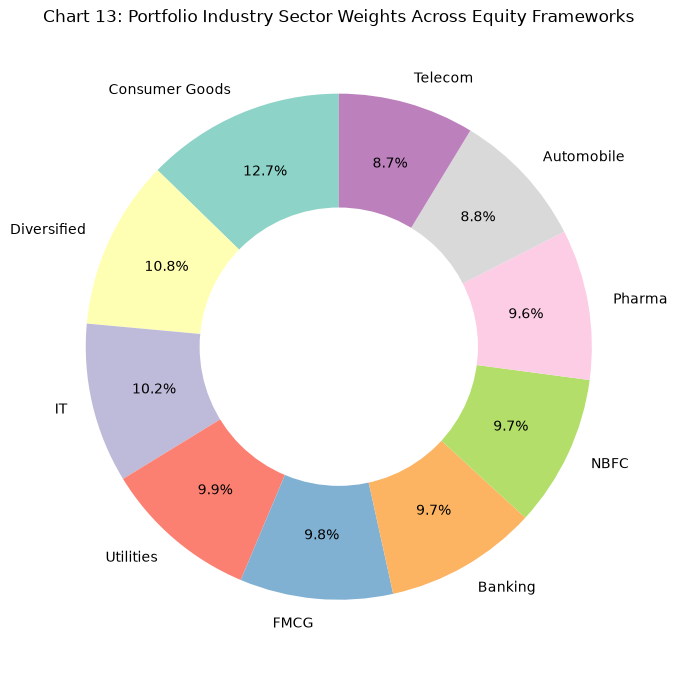

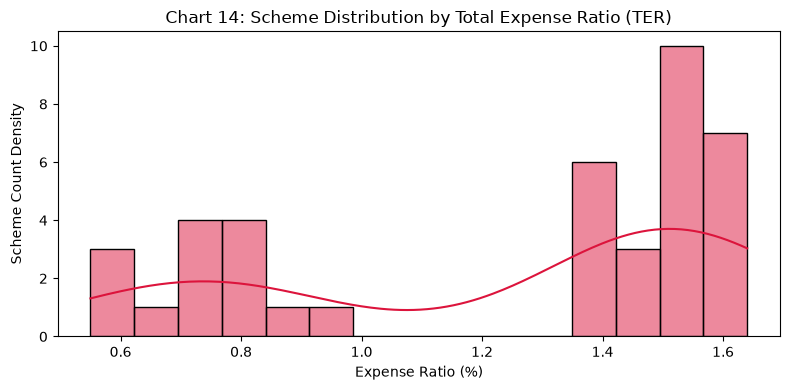

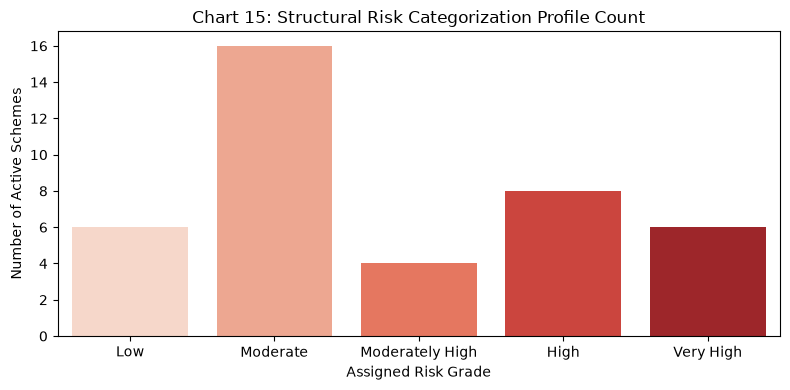

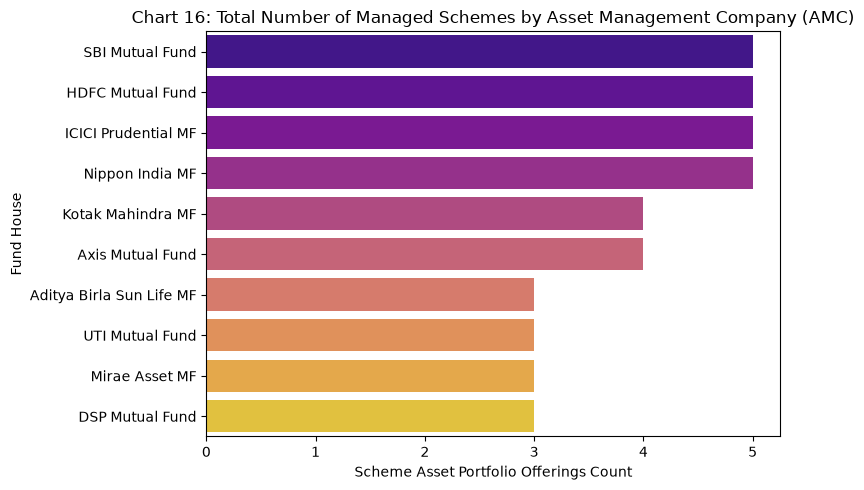

In [30]:
# CELL 5: Correlations, Sectors & Advanced Profiles

df_perf = pd.read_csv("D:/capstone/data/processed/scheme_performance_cleaned.csv")



nav_pivot = df_nav_full.pivot_table(index='date', columns='scheme_name', values='nav')
daily_returns = nav_pivot.pct_change().dropna()
top_10_funds = daily_returns.count().nlargest(10).index
corr_matrix = daily_returns[top_10_funds].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Chart 12: NAV Daily Return Correlation Matrix (Top 10 Active Funds)')
plt.tight_layout()
plt.savefig("exports/charts/12_nav_correlation.png")
plt.show()


sector_weights = df_holdings.groupby('sector')['weight_pct'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(7, 7))
plt.pie(sector_weights, labels=sector_weights.index, autopct='%1.1f%%', startangle=90, pctdistance=0.75, colors=sns.color_palette("Set3"))
plt.gca().add_artist(plt.Circle((0,0), 0.55, fc='white'))
plt.title('Chart 13: Portfolio Industry Sector Weights Across Equity Frameworks')
plt.tight_layout()
plt.savefig("exports/charts/13_sector_allocation.png")
plt.show()


plt.figure(figsize=(8, 4))
sns.histplot(df_perf['expense_ratio_pct'].dropna(), kde=True, color='crimson', bins=15)
plt.title('Chart 14: Scheme Distribution by Total Expense Ratio (TER)')
plt.xlabel('Expense Ratio (%)')
plt.ylabel('Scheme Count Density')
plt.tight_layout()
plt.savefig("exports/charts/14_expense_ratio_distribution.png")
plt.show()


plt.figure(figsize=(8, 4))
sns.countplot(data=df_perf, x='risk_grade', order=['Low', 'Moderate', 'Moderately High', 'High', 'Very High'], palette='Reds')
plt.title('Chart 15: Structural Risk Categorization Profile Count')
plt.xlabel('Assigned Risk Grade')
plt.ylabel('Number of Active Schemes')
plt.tight_layout()
plt.savefig("exports/charts/15_risk_grade_counts.png")
plt.show()


plt.figure(figsize=(8, 5))
house_counts = df_fund['fund_house'].value_counts()
sns.barplot(x=house_counts.values, y=house_counts.index, palette='plasma')
plt.title('Chart 16: Total Number of Managed Schemes by Asset Management Company (AMC)')
plt.xlabel('Scheme Asset Portfolio Offerings Count')
plt.ylabel('Fund House')
plt.tight_layout()
plt.savefig("exports/charts/16_amc_scheme_count.png")
plt.show()

# 10 Key EDA Findings & Business Insights

1. **Market Bull Cycles:** Daily NAV parameters show structural synchronization across all 40 active schemes throughout the 2023 Bull Run timeline, displaying clean resilience across indices (*Ref: 01_nav_trend.png*).
2. **Institutional Market Share:** SBI Mutual Fund controls a massive volume dominance tier, stretching away from peer asset hubs to cross ₹12.5L Crore AUM (*Ref: 02_aum_growth.png*).
3. **Inelastic Capital Flows:** Monthly SIP volumes showed consistent growth regardless of short-term volatility, compounding smoothly to establish an all-time record apex of ₹31,002 Cr in late 2025 (*Ref: 03_sip_inflows.png*).
4. **Segment Allocation Velocity:** Systematic rotation behavior highlights capital drifting into Small/Mid-cap groupings during high-beta intervals (*Ref: 04_category_heatmap.png*).
5. **Generational Asset Split:** While younger age demographics (18-25) hold high participation frequency, intermediate core age bands (36-45) control higher concentration box margins (*Ref: 06_demographics_boxplot.png*).
6. **Demographic Inclusion Window:** The severe historical skew between active gender metrics signals a large unreached market vector for structural targeted outreach (*Ref: 07_demographics_gender.png*).
7. **B30 Market Dispersion:** Beyond classic tier centers, non-metro market clusters (B30) have advanced significantly to hold reliable processing shares (*Ref: 09_geographic_tier.png*).
8. **Geographic Engine Hubs:** Macro financial commitment parameters remain heavily clustered around Tier-1 standard states, leaving rural gaps open (*Ref: 08_geographic_states.png*).
9. **Retail Account Compounding:** Total tracking folio indices essentially doubled within a 4-year processing sequence, ascending directly from 13.26 Cr to 26.12 Cr units (*Ref: 10_folio_total_growth.png*).
10. **Systemic Structural Sector Risk:** Cross-portfolio weight patterns reveal concentration choices heavily weighted towards major banking institutions, tying overall index NAV elasticity close to interest rate adjustment cycles (*Ref: 13_sector_allocation.png*).